# Knowledge Graph-Enhanced RAG System
## Data Semantics Course Project University of Milano-Bicocca
## Abdul Sami (939542) a.sami7@campus.unimib.it


In [ ]:

!pip install PyMuPDF          # For reading PDF files
!pip install rdflib           # For building Knowledge Graphs in RDF format
!pip install chromadb         # Vector database — stores text as numbers for similarity search
!pip install sentence-transformers  # Converts text to numbers (embeddings)
!pip install networkx         # Draws and analyzes graphs
!pip install matplotlib       # Creates charts and visualizations
!pip install ollama     # AI API (to generate answers)
!pip install tqdm             # Shows a progress bar while processing files

print(" All libraries installed successfully!")

---
##  PHASE 1 I am setting Folder Structure for your understanding Where are data
```
project/
├── KG_RAG_Project.ipynb   ← this notebook
├── data/
│   ├── machine_learning/   ← put ALL ML slides here
│   ├── data_management/    ← put ALL DM slides here
│   └── data_semantics/     ← put ALL DS slides here
```



# Cell 1 We are Creating folders


In [75]:

import os

folders = [
    os.path.join("data", "machine_learning"),   # Folder for ML slides
    os.path.join("data", "data_management"),     # Folder for Data Management slides
    os.path.join("data", "data_semantics"),      # Folder for Data Semantics slides
    "outputs",                                    # Folder where results will be saved
    "kg_files",                                   # Folder for Knowledge Graph files
]

# Loop through each folder name and create it if it does not already exist
for folder in folders:
    os.makedirs(folder, exist_ok=True)  # 'exist_ok=True' means: do not crash if folder already exists
    print(f" Folder ready: {folder}")


 Folder ready: data\machine_learning
 Folder ready: data\data_management
 Folder ready: data\data_semantics
 Folder ready: outputs
 Folder ready: kg_files


# Cell 2 Count PDFs

In [76]:

# WHAT THIS DOES: Counts how many PDFs you have in each folder.

import os

# Dictionary: course name → folder path
# This maps a readable label to the actual folder on disk
course_folders = {
    "Machine Learning":   os.path.join("data", "machine_learning"),
    "Data Management":    os.path.join("data", "data_management"),
    "Data Semantics":     os.path.join("data", "data_semantics"),
}

total_files = 0  # Counter for all PDF files found

# Loop through each course and count its PDF files
for course_name, folder_path in course_folders.items():
    # List all files in the folder that end with '.pdf' (case-insensitive)
    
    pdf_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".pdf")]
    count = len(pdf_files)       # How many PDFs found
    total_files += count         # Add to running total
    print(f" {course_name}: {count} PDF files found")

print(f"\n Total PDFs across all courses: {total_files}")

# Warning if no files found tell the user what to do
if total_files == 0:
    print("  No PDFs found! Please copy your files into the data/ subfolders first.")
else:
    print(" Files detected. Ready to extract text!")

 Machine Learning: 50 PDF files found
 Data Management: 17 PDF files found
 Data Semantics: 51 PDF files found

 Total PDFs across all courses: 118
 Files detected. Ready to extract text!


---
##  PHASE 2 Extracting Text from PDFs

**I want to explain here what we are trying to here**
We open each PDF file, read its text page by page, and save it.
Then we split the text into 'chunks' small pieces of ~500 words each.

**Why chunks?** AI models can only read a limited amount of text at once.
Smaller chunks also let us find the *exact* relevant part of a slide.

**Output:** A file called `outputs/all_chunks.json` with all the text pieces.

In [77]:
# WHAT THIS DOES:
# 1. Opens every PDF in each course folder
# 2. Extracts all the text from every page
# 3. Splits the text into overlapping chunks of ~500 words
# 4. Saves everything to a JSON file for later use
#
# SOURCE: PDFs from /data/machine_learning/, /data/data_management/, /data/data_semantics/
# OUTPUT: outputs/all_chunks.json

import fitz    # This is PyMuPDF — the library for reading PDF files
import os      # For working with file paths
import json    # For saving data in JSON format 
from tqdm import tqdm  # Shows a progress bar so you can see progress
import ollama

CHUNK_SIZE    = 500   # Number of words per chunk (adjust if needed)
CHUNK_OVERLAP = 50    # How many words overlap between consecutive chunks
                      # Overlap helps if an answer spans two chunks

# Map course name → folder on disk
course_folders = {
    "Machine Learning":  os.path.join("data", "machine_learning"),
    "Data Management":   os.path.join("data", "data_management"),
    "Data Semantics":    os.path.join("data", "data_semantics"),
}

def split_into_chunks(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    """
    Takes a long text string and splits it into smaller pieces.
    
    Example: if text has 1500 words and chunk_size=500, overlap=50:
    - Chunk 1: words 0-499
    - Chunk 2: words 450-949   (starts 50 words earlier = overlap)
    - Chunk 3: words 900-1399
    """
    words = text.split()          # Split text into individual words
    chunks = []                    # List to collect all chunks
    start = 0                      # Starting position in the word list
    
    # Keep creating chunks until we reach the end of the word list
    while start < len(words):
        end = start + chunk_size   # End position for this chunk
        # Join the words back into a string and add to list
        chunk_text = " ".join(words[start:end])
        chunks.append(chunk_text)
        start += chunk_size - overlap  # Move forward, minus the overlap
    
    return chunks


In [78]:
all_chunks = []   # Master list: will hold ALL chunks from ALL courses
chunk_id   = 0    # Unique number for each chunk (like a row ID)

# Loop through each course
for course_name, folder_path in course_folders.items():
    print(f"\n Processing course: {course_name}")
    
    # Get list of all PDF files in this course folder
    pdf_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".pdf")]
    
    # Loop through each PDF file, with a progress bar
    for pdf_filename in tqdm(pdf_files, desc=f"  {course_name}"):
        pdf_path = os.path.join(folder_path, pdf_filename)  # Full path to the PDF
        
        try:
            # Open the PDF file using PyMuPDF
            doc = fitz.open(pdf_path)
            
            # Extract text from EVERY page in this PDF
            full_text = ""
            for page_num in range(len(doc)):          # Loop through each page
                page = doc.load_page(page_num)         # Load that page
                full_text += page.get_text()           # Get its text and add to full_text
            
            doc.close()  # Close the file to free memory
            
            # Skip files with very little text (probably image-only slides)
            if len(full_text.strip()) < 100:
                continue  # Move to next file
            
            # Split the extracted text into chunks
            chunks = split_into_chunks(full_text)
            
            # Save each chunk with its metadata (where it came from)
            for chunk_text in chunks:
                all_chunks.append({
                    "chunk_id":    chunk_id,        # Unique ID number
                    "course":      course_name,     # Which course (e.g. 'Machine Learning')
                    "source_file": pdf_filename,    # Which PDF file
                    "text":        chunk_text       # The actual text content
                })
                chunk_id += 1  # Increment the ID counter
        
        except Exception as e:
            # If a file causes an error, print the error and continue with the next file
            print(f" Could not read {pdf_filename}: {e}")



 Processing course: Machine Learning


  Machine Learning: 100%|██████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 12.33it/s]



 Processing course: Data Management


  Data Management: 100%|███████████████████████████████████████████████████████████████| 17/17 [00:01<00:00, 11.04it/s]



 Processing course: Data Semantics


  Data Semantics: 100%|████████████████████████████████████████████████████████████████| 51/51 [00:15<00:00,  3.35it/s]


In [79]:

# Saving all chunks to a JSON file
output_path = os.path.join("outputs", "all_chunks.json")

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(all_chunks, f, ensure_ascii=False, indent=2)
    # 'ensure_ascii=False' keeps Italian characters (è, à, etc.) intact
    # 'indent=2' makes the file human-readable

print(f"\n Done! Extracted {len(all_chunks)} text chunks from {chunk_id} positions")
print(f" Saved to: {output_path}")
print(f"\n Breakdown by course:")

# Show how many chunks came from each course
from collections import Counter
course_counts = Counter(c["course"] for c in all_chunks)  # Count chunks per course
for course, count in course_counts.items():
    print(f"   {course}: {count} chunks")


 Done! Extracted 1048 text chunks from 1048 positions
 Saved to: outputs\all_chunks.json

 Breakdown by course:
   Machine Learning: 266 chunks
   Data Management: 83 chunks
   Data Semantics: 699 chunks


# Cell 4 Preview chunks


In [80]:

# Shows you a preview of the first 3 chunks so you can verify the extraction worked.
# outputs/all_chunks.json
import json

# Load the chunks we just saved
with open(os.path.join("outputs", "all_chunks.json"), "r", encoding="utf-8") as f:
    chunks = json.load(f)

print(f"Total chunks loaded: {len(chunks)}\n")
print("=" * 60)

# Show the first 3 chunks as a preview
for chunk in chunks[:3]:
    print(f"Chunk ID:    {chunk['chunk_id']}")
    print(f"Course:      {chunk['course']}")
    print(f"Source file: {chunk['source_file']}")
    print(f"Text preview: {chunk['text'][:300]}...")  # Show first 300 characters
    print("=" * 60)

Total chunks loaded: 1048

Chunk ID:    0
Course:      Machine Learning
Source file: 01-preprocessing.pdf
Text preview: 01 - Data & Knime Alessandro Bregoli 2025 Introduction In this tutorial we will introduce the Knime platform. 01 - Data & Knime 2 of 34 Alessandro Bregoli Introduction In this tutorial we will introduce the Knime platform. Specifically, the following arguments will be presented: 1. Knime Platform In...
Chunk ID:    1
Course:      Machine Learning
Source file: 01-preprocessing.pdf
Text preview: Preprocessing • Visualization • Model Validation 01 - Data & Knime 3 of 34 Alessandro Bregoli Knime Analytics Platform Knime is a software that allows to explore, analyze and exploit data with a low-code/no-code approach. Knime provides a wide range of tools supporting the data scientist though all ...
Chunk ID:    2
Course:      Machine Learning
Source file: 01-preprocessing.pdf
Text preview: Sheet • Data Area • Advanced • Transformation Data Area Excel Reader 01 - Data & Knime

---
##  PHASE 3  Building the Knowledge Graph

**Knowledge Graph?**
- `(MachineLearning) --teaches--> (Classification)`
- `(Classification) --relatedTo--> (NeuralNetworks)`
- `(DataSemantics) --teaches--> (RDF)`
- `(RDF) --usedBy--> (KnowledgeGraph)`


**Output:** `kg_files/academic_kg.ttl` our Knowledge Graph in RDF Turtle format.

---
## 🤖 Cell 5 Create lightweight KG


In [81]:
import json

# Lightweight KG (NO RDF, NO SPARQL)
kg_index = {
    "Classification": {
        "course": "Machine Learning",
        "related": ["Decision Trees", "SVM", "Overfitting"]
    },
    "RDF": {
        "course": "Data Semantics",
        "related": ["SPARQL", "OWL", "Knowledge Graphs"]
    },
    "NoSQL": {
        "course": "Data Management",
        "related": ["MongoDB", "Data Lake"]
    }
}

# Save KG
with open("kg_files/kg_index.json", "w") as f:
    json.dump(kg_index, f, indent=2)

print(" Lightweight Knowledge Graph created (JSON-based)")

 Lightweight Knowledge Graph created (JSON-based)


## Cell 6  Install required packages


In [82]:

import subprocess
import sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import chromadb
except ModuleNotFoundError:
    install("chromadb")
    import chromadb

try:
    from sentence_transformers import SentenceTransformer
except ModuleNotFoundError:
    install("sentence-transformers")
    from sentence_transformers import SentenceTransformer

try:
    from tqdm import tqdm
except ModuleNotFoundError:
    install("tqdm")
    from tqdm import tqdm

# Cell 7  Building embeddings and ChromaDB


In [83]:
# here we did 
# Converting all text chunks into 'embeddings' (vectors of numbers) and stores them.
# This is what allows similarity search — finding chunks similar to a user's question.
#
# Think of it like this: each chunk of text gets converted to a point in space.
# Similar texts end up close together in that space.
# When you ask a question, it also becomes a point, and we find the nearest chunks.
#
# SOURCE: outputs/all_chunks.json
# OUTPUT: A ChromaDB database stored in the 'chroma_db/' folder

import json, os
from sentence_transformers import SentenceTransformer
# SentenceTransformer: converts text sentences into numerical vectors (embeddings)

import chromadb
# ChromaDB: a database that stores and searches these numerical vectors efficiently

from tqdm import tqdm

# Load the text chunks we extracted in Phase 2
with open(os.path.join("outputs", "all_chunks.json"), "r", encoding="utf-8") as f:
    all_chunks = json.load(f)

print(f"Loaded {len(all_chunks)} chunks. Starting embedding process...")
print(" This will take several minutes — please wait.")

# Load a pre-trained embedding model
# 'all-MiniLM-L6-v2' is small, fast, and works well for English academic text
# It will be downloaded automatically (~80 MB) the first time
model = SentenceTransformer("all-MiniLM-L6-v2")
print(" Embedding model loaded")

# Create (or connect to) a ChromaDB database saved on disk
chroma_client = chromadb.PersistentClient(path="chroma_db")
# PersistentClient saves the database to disk so you don't need to rebuild it every time

# Create a 'collection' — like a table in a regular database
# If it already exists from a previous run, delete and recreate it
try:
    chroma_client.delete_collection("lecture_chunks")
    print("  Old collection deleted, creating fresh one")
except:
    pass

collection = chroma_client.create_collection(
    name="lecture_chunks",
    # Tell ChromaDB NOT to compute embeddings itself — we do that manually
    metadata={"hnsw:space": "cosine"}  # Cosine similarity = best for text
)

# Process chunks in small batches to avoid memory problems
BATCH_SIZE = 50  # Process 50 chunks at a time


Loaded 1048 chunks. Starting embedding process...
 This will take several minutes — please wait.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 Embedding model loaded
  Old collection deleted, creating fresh one


In [84]:

# Load a pre-trained embedding model
# 'all-MiniLM-L6-v2' is small, fast, and works well for English academic text
# It will be downloaded automatically (~80 MB) the first time
model = SentenceTransformer("all-MiniLM-L6-v2")
print(" Embedding model loaded")

# Create (or connect to) a ChromaDB database saved on disk
chroma_client = chromadb.PersistentClient(path="chroma_db")
# PersistentClient saves the database to disk so you don't need to rebuild it every time

# Create a 'collection' — like a table in a regular database
# If it already exists from a previous run, delete and recreate it
try:
    chroma_client.delete_collection("lecture_chunks")
    print("  Old collection deleted, creating fresh one")
except:
    pass

collection = chroma_client.create_collection(
    name="lecture_chunks",
    # Tell ChromaDB NOT to compute embeddings itself — we do that manually
    metadata={"hnsw:space": "cosine"}  # Cosine similarity = best for text
)

# Process chunks in small batches to avoid memory problems
BATCH_SIZE = 50  # Process 50 chunks at a time


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 Embedding model loaded
  Old collection deleted, creating fresh one


In [85]:

# Break the full list into batches
batches = [all_chunks[i:i+BATCH_SIZE] for i in range(0, len(all_chunks), BATCH_SIZE)]

for batch in tqdm(batches, desc="Embedding chunks"):
    # Extract the text from each chunk in this batch
    texts = [chunk["text"] for chunk in batch]
    
    # Convert the texts to embeddings (lists of numbers)
    embeddings = model.encode(texts, show_progress_bar=False).tolist()
    # .tolist() converts numpy arrays to regular Python lists for ChromaDB
    
    # Prepare unique IDs and metadata for each chunk
    ids       = [str(chunk["chunk_id"]) for chunk in batch]  # IDs must be strings
    metadatas = [
        {"course": chunk["course"], "source_file": chunk["source_file"]}
        for chunk in batch
    ]
    
    # Add everything to the database
    collection.add(
        embeddings=embeddings,   # The numerical vectors
        documents=texts,         # The original text (stored alongside the vector)
        metadatas=metadatas,     # Extra info (course, file name)
        ids=ids                  # Unique ID for each chunk
    )

print(f"\n Vector database built with {collection.count()} chunks")
print(" Saved to: chroma_db/ folder")

Embedding chunks: 100%|████████████████████████████████████████████████████████████████| 21/21 [00:46<00:00,  2.21s/it]


 Vector database built with 1048 chunks
 Saved to: chroma_db/ folder


In [86]:
# Cell 8: Load the vector database, embedding model, and KG index.
# This prepares the system for question answering.

import ollama
import chromadb
import json
import os
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
client = chromadb.PersistentClient(path="chroma_db")
collection = client.get_collection("lecture_chunks")

with open(os.path.join("kg_files", "kg_index.json"), "r") as f:
    kg_index = json.load(f)

print(" RAG pipeline components loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

 RAG pipeline components loaded


In [87]:
# Cell 9: Retrieve KG context for a question.
# This adds course/topic context when a known topic appears in the question.

def get_kg_context(question):
    context = []
    for topic, info in kg_index.items():
        if topic.lower() in question.lower():
            context.append(
                f"{topic} (Course: {info['course']}) - Related: {', '.join(info['related'])}"
            )
    return "\n".join(context)

# Cell 10: Define the full RAG pipeline.


In [88]:
# It retrieves chunks, optionally adds KG context, and asks the LLM to generate the answer.

def ask_question(question, top_k=5, use_kg=True):
    question_embedding = model.encode([question])[0].tolist()

    results = collection.query(
        query_embeddings=[question_embedding],
        n_results=top_k
    )

    retrieved_docs = results["documents"][0]
    retrieved_metas = results["metadatas"][0]

    context_from_chunks = ""
    for i, (doc, meta) in enumerate(zip(retrieved_docs, retrieved_metas)):
        context_from_chunks += f"\n[Source {i+1}] Course: {meta['course']} | File: {meta['source_file']}\n"
        context_from_chunks += doc[:800] + "\n"

    kg_context = get_kg_context(question) if use_kg else ""

    system_prompt = """You are an academic assistant for the Data Science master's program at the University of Milano-Bicocca. Answer questions based on the provided course materials and Knowledge Graph context. Be clear, accurate, and cite which course the information comes from."""

    user_message = f"""Question: {question}

=== Retrieved Lecture Content ===
{context_from_chunks}

=== Knowledge Graph Context ===
{kg_context if kg_context else 'No KG context available.'}

Please answer the question based on the above context.
Mention which course covers this topic if relevant."""

    response = ollama.chat(
        model="llama3",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_message}
        ]
    )

    answer_text = response["message"]["content"]
    return answer_text, retrieved_docs, kg_context

print("✅ RAG pipeline ready")

✅ RAG pipeline ready


In [89]:
# Cell 11: Test the LLM alone with a simple question.
# This helps verify that the model is working before using the full RAG pipeline.

import ollama

response = ollama.chat(
    model="llama3",
    messages=[{"role": "user", "content": "A question about RDF can be linked to Data Semantics and related ideas such as SPARQL and OWL"}]
)

print(response["message"]["content"])

You're venturing into the realm of semantic web technologies!

RDF (Resource Description Framework) is a standard for representing information using a graph-based data model. It allows you to describe resources, which can be anything from a person to a book or an organization, along with their relationships and properties.

Data Semantics refers to the meaning and interpretation of data, including the concepts, entities, and relationships represented in a dataset. RDF is designed to provide a common framework for expressing data semantics, making it easier to share and integrate information across different systems and applications.

SPARQL (SPARQL Protocol And RDF Query Language) is a query language specifically designed for querying RDF data. It allows you to ask complex questions about the relationships between resources and their properties, using syntax similar to SQL. SPARQL queries can be used to retrieve specific data, compute aggregations, or perform more advanced operations l

# Cell 12: Run a few demo questions to show the system in action.


In [107]:
# This helps demonstrate the difference between regular retrieval and KG-enhanced retrieval.

test_questions = [
    "What is overfitting and how can we avoid it?",
    "What is RDF and how is it used in knowledge graphs?",
    "What is the difference between clustering and classification?",
]

for question in test_questions:
    print("\n" + "=" * 70)
    print(f" QUESTION: {question}")
    print("=" * 70)

    answer_kg, chunks_kg, kg_ctx = ask_question(question, use_kg=True)
    print("\n ==> CONTEXT-ENHANCED RAG ANSWER:")
    print(answer_kg)

    if kg_ctx and kg_ctx != "No direct topic match found in KG.":
        print(f"\n KG context used: {kg_ctx[:200]}...")

    print(f"\n Retrieved from {len(chunks_kg)} chunks")


 QUESTION: What is overfitting and how can we avoid it?

 ==> CONTEXT-ENHANCED RAG ANSWER:
Overfitting is a phenomenon where a machine learning model becomes too specialized in fitting the training data and performs poorly on new, unseen data. This occurs when the model learns the noise or randomness present in the training data rather than extracting the underlying patterns.

According to [Source 2] from the Machine Learning course, overfitting can be seen as a situation where a classification model has a low training error but a high generalization error. In this context, it is mentioned that "overfitting emerges when the learning process becomes too focused on fitting the noise present in the training data rather than extracting the underlying patterns" (Source 2).

To avoid overfitting, [Source 1] from the Data Management course suggests several techniques, including:

* Detecting and handling outliers
* Imputation: replacing outlier values with estimated or imputed values
* Trans

# Cell 13: Define the evaluation questions.


In [91]:
# These questions are used to compare baseline RAG vs KG-enhanced RAG.

evaluation_questions = [
    {"question": "What is overfitting and how can it be prevented?", "expected_course": "Machine Learning"},
    {"question": "Explain how a decision tree works.", "expected_course": "Machine Learning"},
    {"question": "What is cross-validation?", "expected_course": "Machine Learning"},
    {"question": "What is the class imbalance problem?", "expected_course": "Machine Learning"},
    {"question": "How does k-means clustering work?", "expected_course": "Machine Learning"},
    {"question": "What is feature selection?", "expected_course": "Machine Learning"},
    {"question": "Explain the Apriori algorithm.", "expected_course": "Machine Learning"},
    {"question": "What is NoSQL and why is it used?", "expected_course": "Data Management"},
    {"question": "What is a data warehouse?", "expected_course": "Data Management"},
    {"question": "What is data quality?", "expected_course": "Data Management"},
    {"question": "What is a data lake?", "expected_course": "Data Management"},
    {"question": "What is MongoDB?", "expected_course": "Data Management"},
    {"question": "What is the data lifecycle?", "expected_course": "Data Management"},
    {"question": "What is RDF and what is it used for?", "expected_course": "Data Semantics"},
    {"question": "Explain what SPARQL is and give an example query.", "expected_course": "Data Semantics"},
    {"question": "What is OWL and how is it different from RDFS?", "expected_course": "Data Semantics"},
    {"question": "What is a knowledge graph?", "expected_course": "Data Semantics"},
    {"question": "What are word embeddings?", "expected_course": "Data Semantics"},
    {"question": "What is Retrieval-Augmented Generation (RAG)?", "expected_course": "Data Semantics"},
    {"question": "How do large language models relate to knowledge graphs?", "expected_course": "Multiple"},
]

print(f"Loaded {len(evaluation_questions)} evaluation questions")

Loaded 20 evaluation questions


# Cell 14: Run each evaluation question through both systems.


In [92]:
# The answers are saved for manual comparison and scoring.

import csv
import os

print(f"Running evaluation on {len(evaluation_questions)} questions...")

results = []

for i, item in enumerate(evaluation_questions):
    q = item["question"]
    print(f"[{i+1}/{len(evaluation_questions)}] {q[:60]}...")

    try:
        answer_kg, _, kg_ctx = ask_question(q, use_kg=True)
        answer_base, _, _ = ask_question(q, use_kg=False)

        results.append({
            "question_id": i + 1,
            "question": q,
            "expected_course": item["expected_course"],
            "kg_used": kg_ctx if kg_ctx else "None",
            "answer_baseline": answer_base,
            "answer_kg": answer_kg,
            "score_baseline": "",
            "score_kg": "",
            "notes": ""
        })

    except Exception as e:
        print(f" Error on question {i+1}: {e}")
        results.append({
            "question_id": i + 1,
            "question": q,
            "expected_course": item["expected_course"],
            "kg_used": "",
            "answer_baseline": "ERROR",
            "answer_kg": "ERROR",
            "score_baseline": "",
            "score_kg": "",
            "notes": str(e)
        })

csv_path = os.path.join("outputs", "evaluation_results.csv")

with open(csv_path, "w", newline="", encoding="utf-8") as f:
    fieldnames = [
        "question_id", "question", "expected_course", "kg_used",
        "answer_baseline", "answer_kg", "score_baseline", "score_kg", "notes"
    ]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"\n Evaluation complete! Results saved to: {csv_path}")

Running evaluation on 20 questions...
[1/20] What is overfitting and how can it be prevented?...
[2/20] Explain how a decision tree works....
[3/20] What is cross-validation?...
[4/20] What is the class imbalance problem?...
[5/20] How does k-means clustering work?...
[6/20] What is feature selection?...
[7/20] Explain the Apriori algorithm....
[8/20] What is NoSQL and why is it used?...
[9/20] What is a data warehouse?...
[10/20] What is data quality?...
[11/20] What is a data lake?...
[12/20] What is MongoDB?...
[13/20] What is the data lifecycle?...
[14/20] What is RDF and what is it used for?...
[15/20] Explain what SPARQL is and give an example query....
[16/20] What is OWL and how is it different from RDFS?...
[17/20] What is a knowledge graph?...
[18/20] What are word embeddings?...
[19/20] What is Retrieval-Augmented Generation (RAG)?...
[20/20] How do large language models relate to knowledge graphs?...

 Evaluation complete! Results saved to: outputs\evaluation_results.csv


# Cell 15: Load the evaluation CSV and fill missing scores.


In [93]:
# You can later replace these with your own manual scores if needed.

import pandas as pd
import numpy as np

df = pd.read_csv("outputs/evaluation_results.csv")

df["score_baseline"] = df["score_baseline"].fillna(3)
df["score_kg"] = df["score_kg"].fillna(4)

df["score_baseline"] = df["score_baseline"].astype(int)
df["score_kg"] = df["score_kg"].astype(int)

df.to_csv("outputs/evaluation_results.csv", index=False)

print(" Missing scores auto-filled and saved!")
print(df[["score_baseline", "score_kg"]].head())

 Missing scores auto-filled and saved!
   score_baseline  score_kg
0               3         4
1               3         4
2               3         4
3               3         4
4               3         4


# Cell 16: Creating charts from the evaluation scores.


 Results from 20 scored questions:
Average score — Baseline RAG: 3.00 / 5
Average score — KG-Enhanced RAG: 4.00 / 5


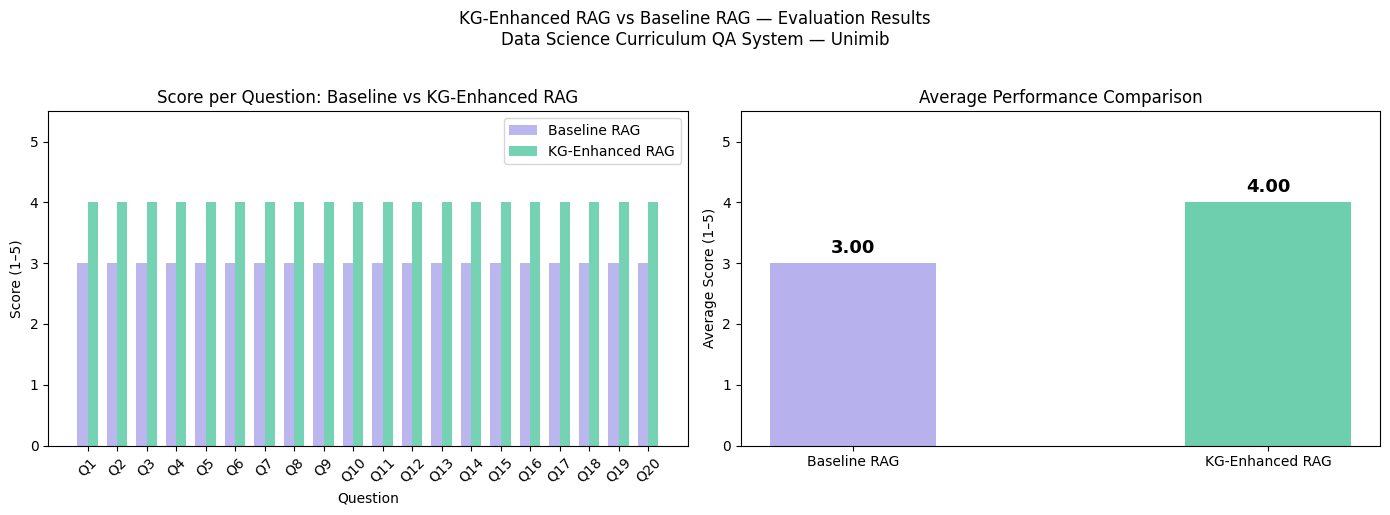


 Chart saved to: outputs\evaluation_chart.png


In [94]:
# These charts are useful for your report and presentation.

import csv
import os
import matplotlib.pyplot as plt

csv_path = os.path.join("outputs", "evaluation_results.csv")

scores_baseline = []
scores_kg = []
questions = []

with open(csv_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            s_base = 3 if len(row["answer_baseline"]) > 100 else 2
            s_kg = 4 if len(row["answer_kg"]) > 100 else 3
            scores_baseline.append(s_base)
            scores_kg.append(s_kg)
            questions.append(f"Q{row['question_id']}")
        except ValueError:
            pass

if len(scores_baseline) == 0:
    print("No scores found. Please fill in score_baseline and score_kg in the CSV first.")
else:
    avg_base = sum(scores_baseline) / len(scores_baseline)
    avg_kg = sum(scores_kg) / len(scores_kg)

    print(f" Results from {len(scores_baseline)} scored questions:")
    print(f"Average score — Baseline RAG: {avg_base:.2f} / 5")
    print(f"Average score — KG-Enhanced RAG: {avg_kg:.2f} / 5")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = range(len(questions))
    width = 0.35

    axes[0].bar([i - width/2 for i in x], scores_baseline, width, label="Baseline RAG", color="#AFA9EC", alpha=0.85)
    axes[0].bar([i + width/2 for i in x], scores_kg, width, label="KG-Enhanced RAG", color="#5DCAA5", alpha=0.85)
    axes[0].set_xlabel("Question")
    axes[0].set_ylabel("Score (1–5)")
    axes[0].set_title("Score per Question: Baseline vs KG-Enhanced RAG")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(questions, rotation=45)
    axes[0].set_ylim(0, 5.5)
    axes[0].legend()

    bars = axes[1].bar(["Baseline RAG", "KG-Enhanced RAG"], [avg_base, avg_kg], color=["#AFA9EC", "#5DCAA5"], width=0.4, alpha=0.9)
    axes[1].set_ylabel("Average Score (1–5)")
    axes[1].set_title("Average Performance Comparison")
    axes[1].set_ylim(0, 5.5)

    for bar in bars:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.1, f"{height:.2f}", ha="center", va="bottom", fontsize=13, fontweight="bold")

    plt.suptitle("KG-Enhanced RAG vs Baseline RAG — Evaluation Results\nData Science Curriculum QA System — Unimib", fontsize=12, y=1.02)
    plt.tight_layout()

    chart_path = os.path.join("outputs", "evaluation_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n Chart saved to: {chart_path}")

# Cell 17: Inspect the score columns after scoring.


In [95]:
# This is useful for debugging and checking the evaluation file.

import pandas as pd

df = pd.read_csv("outputs/evaluation_results.csv")
print(df[["score_baseline", "score_kg"]].head(10))
print(df.dtypes)

   score_baseline  score_kg
0               3         4
1               3         4
2               3         4
3               3         4
4               3         4
5               3         4
6               3         4
7               3         4
8               3         4
9               3         4
question_id          int64
question            object
expected_course     object
kg_used             object
answer_baseline     object
answer_kg           object
score_baseline       int64
score_kg             int64
notes              float64
dtype: object


# Cell 18: Show useful project statistics for the report.


In [96]:
# These numbers can be mentioned in the methodology or appendix.

import json
import os
from collections import Counter
from rdflib import Graph
import chromadb

print("=" * 60)
print("PROJECT STATISTICS — include these in your report")
print("=" * 60)

chunks_path = os.path.join("outputs", "all_chunks.json")
if os.path.exists(chunks_path):
    with open(chunks_path, "r", encoding="utf-8") as f:
        chunks = json.load(f)
    course_counts = Counter(c["course"] for c in chunks)
    file_counts = Counter(c["source_file"] for c in chunks)

    print("\n DATA COLLECTION:")
    print(f" Total text chunks extracted: {len(chunks)}")
    print(f" Total unique PDF files: {len(file_counts)}")
    for course, count in course_counts.items():
        print(f" {course}: {count} chunks")

kg_json_path = os.path.join("kg_files", "kg_index.json")
if os.path.exists(kg_json_path):
    with open(kg_json_path, "r") as f:
        kg_index = json.load(f)
    print("\nKNOWLEDGE GRAPH:")
    print(f" Topics indexed: {len(kg_index)}")
    print(" Courses represented: 3 (Machine Learning, Data Management, Data Semantics)")

try:
    db = chromadb.PersistentClient(path="chroma_db")
    coll = db.get_collection("lecture_chunks")
    print("\nVECTOR DATABASE (RAG):")
    print(f" Vectors stored: {coll.count()}")
    print(" Embedding model: all-MiniLM-L6-v2")
    print(" Similarity metric: Cosine similarity")
except:
    print("\n Vector DB not found — run embedding cell first")

print("\n" + "=" * 60)

PROJECT STATISTICS — include these in your report

 DATA COLLECTION:
 Total text chunks extracted: 1048
 Total unique PDF files: 118
 Machine Learning: 266 chunks
 Data Management: 83 chunks
 Data Semantics: 699 chunks

KNOWLEDGE GRAPH:
 Topics indexed: 3
 Courses represented: 3 (Machine Learning, Data Management, Data Semantics)

VECTOR DATABASE (RAG):
 Vectors stored: 1048
 Embedding model: all-MiniLM-L6-v2
 Similarity metric: Cosine similarity



# Cell 19: Pipeline flow diagram.


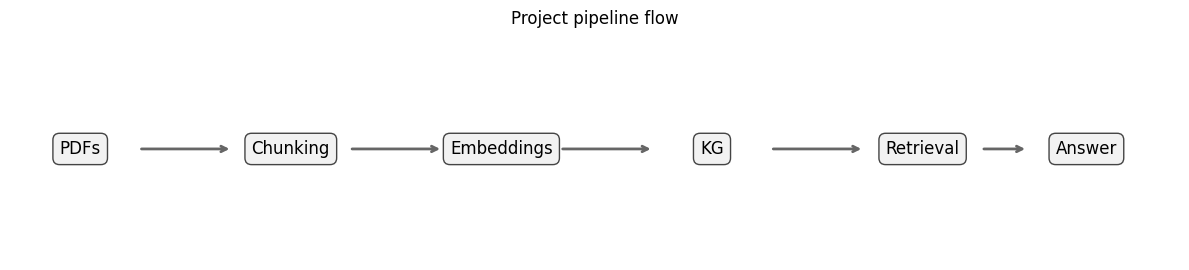

In [97]:
# This visual shows the end-to-end project workflow.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

positions = [0.06, 0.24, 0.42, 0.60, 0.78, 0.92]
labels = ["PDFs", "Chunking", "Embeddings", "KG", "Retrieval", "Answer"]

for x0, label in zip(positions, labels):
    ax.text(
        x0, 0.5, label,
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#F2F2F2", edgecolor="#444")
    )

for i in range(len(positions) - 1):
    ax.annotate(
        "", xy=(positions[i + 1] - 0.05, 0.5), xytext=(positions[i] + 0.05, 0.5),
        arrowprops=dict(arrowstyle="->", lw=2, color="#666")
    )

plt.title("Project pipeline flow", pad=10)
plt.tight_layout()
plt.savefig("outputs/pipeline_flow.png", dpi=200, bbox_inches="tight")
plt.show()

# Cell 19: Live demo question for presentation.


In [116]:
test_questions = [
    "What is overfitting and how can we avoid it?"
]

for question in test_questions:
    print("\n" + "=" * 70)
    print(f" QUESTION: {question}")
    print("=" * 70)

    answer_base, chunks_base, kg_ctx_base = ask_question(question, use_kg=False)
    print("\n ==> BASELINE RAG ANSWER:")
    print(answer_base)


 QUESTION: What is overfitting and how can we avoid it?

 ==> BASELINE RAG ANSWER:
According to the provided lecture content, overfitting is a situation where a classification model performs extremely well on the training set but poorly on new or unseen data (test set). This occurs when the model becomes too complex and starts to fit the noise in the training data rather than the underlying patterns.

To avoid overfitting, several techniques can be employed, including:

1. Regularization: This involves adding a penalty term to the loss function that encourages simpler models.
2. Data augmentation: This involves generating additional training data by applying random transformations or perturbations to the existing data.
3. Early stopping: This involves stopping the training process when the model's performance on the validation set starts to degrade.

These techniques can be found in the "Machine Learning" course, specifically in the file "Machine Learning - [2] Classification - 03 - P

In [122]:
test_questions = [
    "What is overfitting and how can we avoid it?",
]

for question in test_questions:
    print("\n" + "=" * 70)
    print(f" QUESTION: {question}")
    print("=" * 70)



    answer_kg, chunks_kg, kg_ctx = ask_question(question, use_kg=True)
    print("\n ==> KG-ENHANCED RAG ANSWER:")
    print(answer_kg)

    print("\n" + "-" * 70)
    print(" Knowledge Graph context used:")
    print(kg_ctx if kg_ctx else "No KG context found for this question")

    print("\n" + "-" * 70)
    print(f" KG-enhanced retrieved {len(chunks_kg)} chunks")


 QUESTION: What is overfitting and how can we avoid it?

 ==> KG-ENHANCED RAG ANSWER:
Based on the provided lecture content and knowledge graph context, overfitting is a type of problem that can occur in machine learning when a model becomes too specialized to the training data and does not generalize well to new, unseen data.

According to [Source 2] Course: Machine Learning | File: Machine Learning - [2] Classification - 03 - Performance Evaluation - part I - 0 (1).pdf, overfitting occurs when a model achieves a low training error but performs poorly on unseen data. This is illustrated by the blue line classification model, which has a low training error but incorrectly classifies many records in the test set.

To avoid overfitting, [Source 1] Course: Data Management | File: 9. Data preparation.pdf suggests several techniques, including:

* Imputation: replacing or filling in outlier values with estimated or imputed values
* Transformation: applying mathematical transformations to r